In [3]:
import numpy as np

from keras.models import Sequential
from keras.layers import Dense, Dropout

import matplotlib as mpl
import matplotlib.pyplot as plt
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler

%run useful.py
# training/validation/test fractions
perc_train = 0.7
perc_valid = 0.15
perc_test = 0.15
#  check it sums to 1 
assert abs(perc_train + perc_valid + perc_test - 1.0) < 1e-12

In [86]:
TYPE=3
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')

(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 1
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: 8400
valid: 1800
test: 1800


In [112]:
import random
'''
putting in rid the dataset reduced
keeping 50%, 75%, 90%
'''
rid_x = []
rid_y = []
perc_list = [0.5, 0.75, 0.9]
for perc_keep in perc_list:
    indicies = random.sample(range(0,len(x)), int(len(x)*perc_keep))
    x_rid = x[indicies]
    y_rid = y[indicies]
    rid_x.append(x_rid)
    rid_y.append(y_rid)

In [41]:
'''
dividing in training validation and test
'''
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])

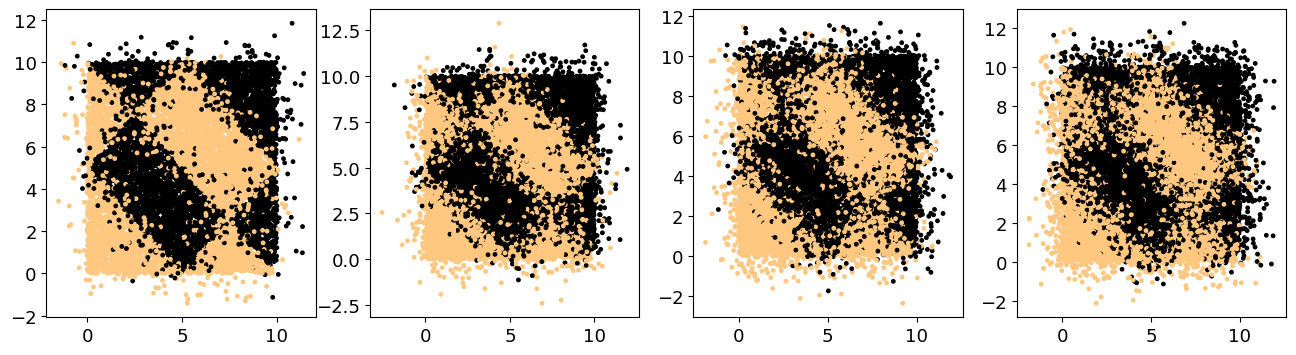

In [124]:
'''
generating training datsets with random gaussian noise
'''
fig, ax = plt.subplots(nrows=1, ncols=4,figsize=(16,4))
perc_aug = [0.2,0.4,0.6,0.8]
aug_xg = []
aug_yg = []
for i,p in enumerate(perc_aug):
    g_noise = np.random.normal(0, 0.8, (int(len(x_train)*p),8))
    indicies = random.sample(range(0,len(x_train)), len(g_noise))
    x_train_new = x_train[indicies] + g_noise
    x_train_g_noise = np.concatenate((x_train, x_train_new))
    y_train_new = y_train[indicies]
    y_train_g_noise = np.concatenate((y_train, y_train_new))
    aug_xg.append(x_train_g_noise)
    aug_yg.append(y_train_g_noise)
    ax[i].scatter(x_train_g_noise[:,0],x_train_g_noise[:,1],s=6,c=y_train_g_noise)

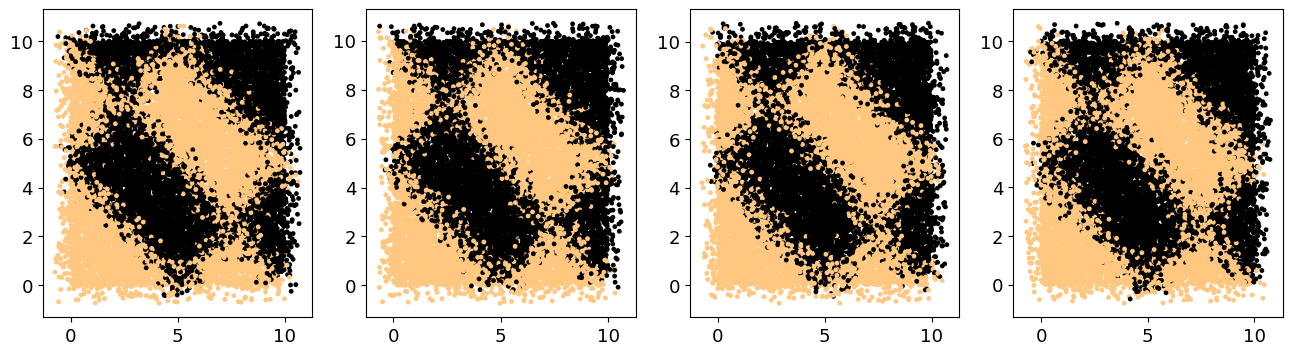

In [125]:
'''
generating training datsets with random exponential noise
'''
fig, ax = plt.subplots(nrows=1, ncols=4,figsize=(16,4))
perc_aug = [0.2,0.4,0.6,0.8]
aug_xe = []
aug_ye = []
for i,p in enumerate(perc_aug):
    e_noise = np.tanh(np.sin(g_noise)) 
    indicies = random.sample(range(0,len(x_train)), len(e_noise))
    x_train_new = x_train[indicies] + e_noise
    x_train_e_noise = np.concatenate((x_train, x_train_new))
    y_train_new = y_train[indicies]
    y_train_e_noise = np.concatenate((y_train, y_train_new))
    aug_xe.append(x_train_e_noise)
    aug_ye.append(y_train_e_noise)
    ax[i].scatter(x_train_e_noise[:,0],x_train_e_noise[:,1],s=6,c=y_train_e_noise)

In [105]:
'''
defining model
'''
model = Sequential()
model.add(Dense(L,input_shape=(L,),activation='relu'))
model.add(Dense(20,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(20,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(20,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))
nepoch=80
print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 20)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,113 (4.35 KB)

 Trainable params: 1,113 (4.35 KB)

 Non-trainable params: 0 (0.00 B)

None


In [106]:
'''
compiling using standard metric
'''
model.compile(loss='binary_crossentropy',
              optimizer='RMSprop',
              #optimizer='adam',
              metrics=['accuracy'])

In [126]:
'''
training of the model on the reduced training sets
'''
Fit_r = []
for x_train_r, y_train_r in zip(rid_x, rid_y):
    fit = model.fit(x_train_r, y_train_r,
               epochs = nepoch, batch_size = 50,
               validation_data=(x_valid,y_valid),
               verbose=0)
    Fit_r.append(fit)

0.10197215527296066


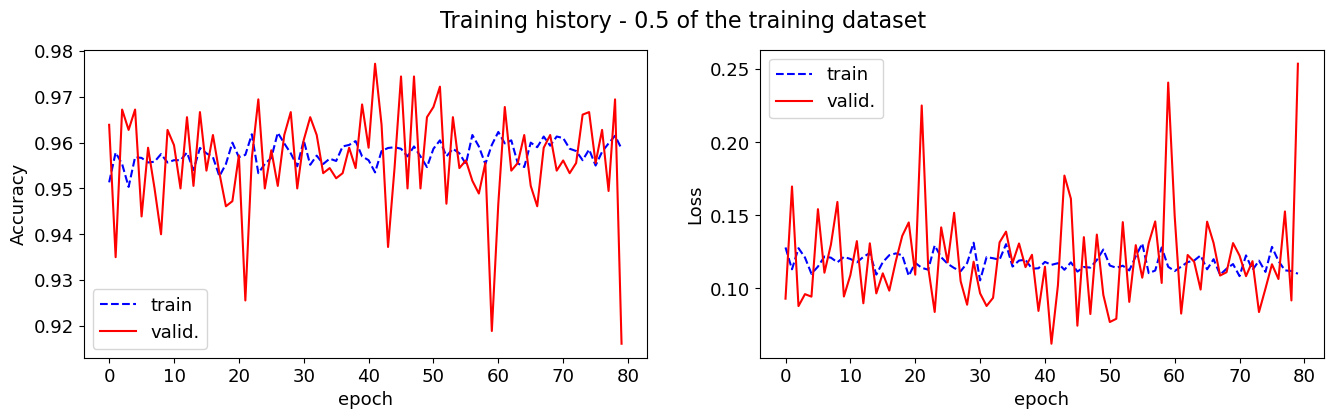

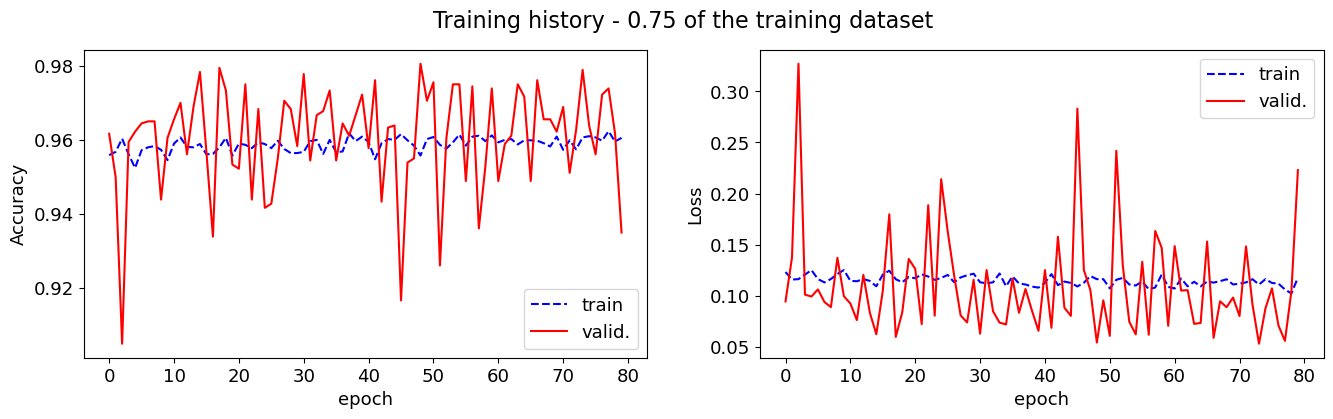

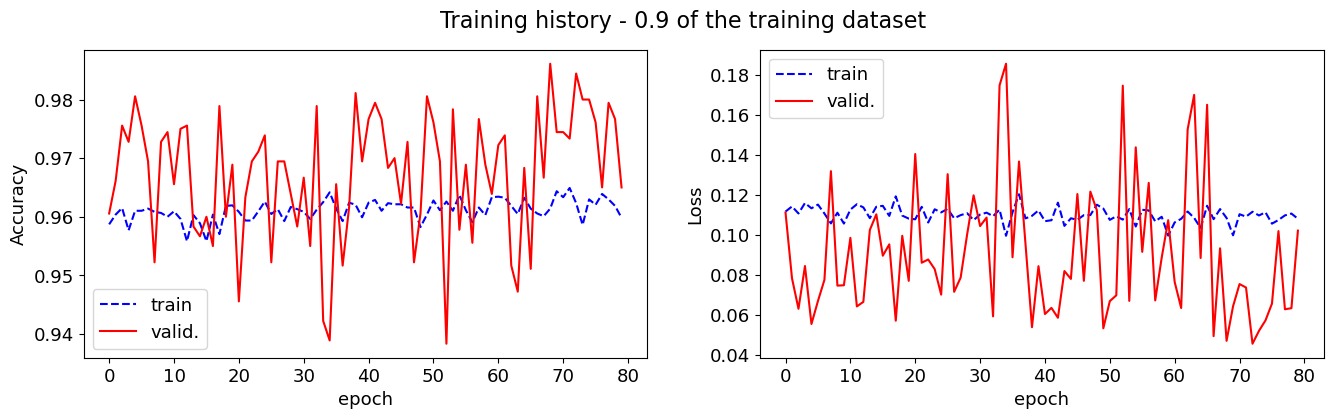

In [131]:
'''
validation for reduced training sets
'''
best_l = 1e9
for i,fit in enumerate(Fit_r):
    fig,AX=plt.subplots(1,2,figsize=(16,4.))
    ax=AX[0]
    fig.suptitle(f'Training history - {perc_list[i]} of the training dataset', fontsize=16)
    ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_loss'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.legend()
    if fit.history['val_loss'][-1] < best_l:
        best_l = fit.history['val_loss'][-1]
        best_fit_r = fit
print(best_l)
print(best_fit_r)

In [132]:
'''
training of the model on the augmented gaussian training sets
'''
Fit_ag = []
for x_train_ag, y_train_ag in zip(aug_xg, aug_yg):
    fit = model.fit(x_train_ag, y_train_ag,
               epochs = nepoch, batch_size = 50,
               validation_data=(x_valid,y_valid),
               verbose=0)
    Fit_ag.append(fit)

1000000000.0


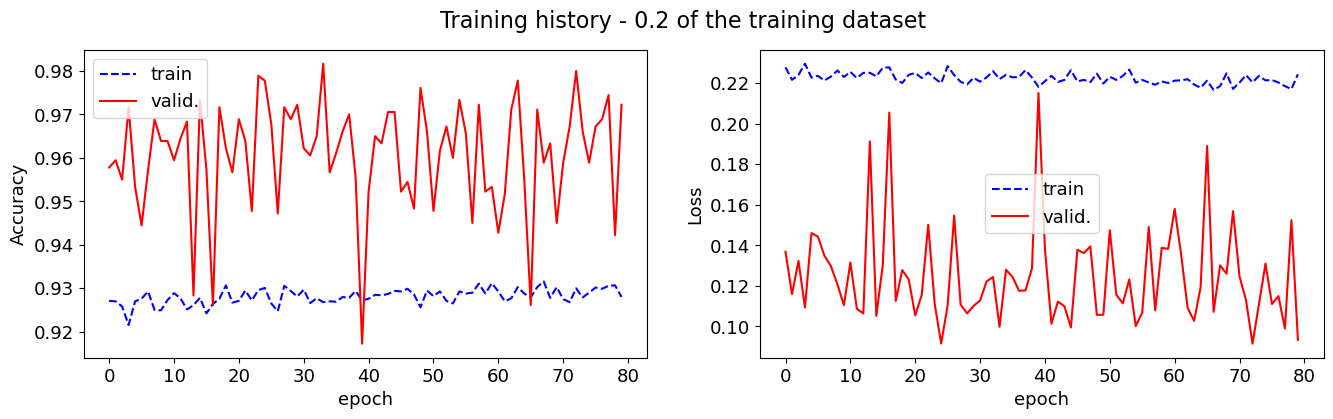

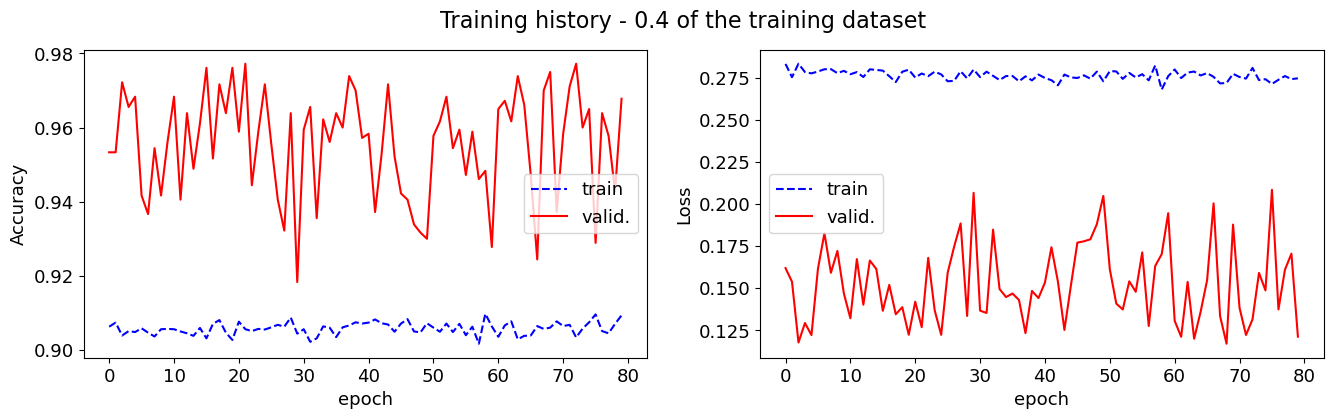

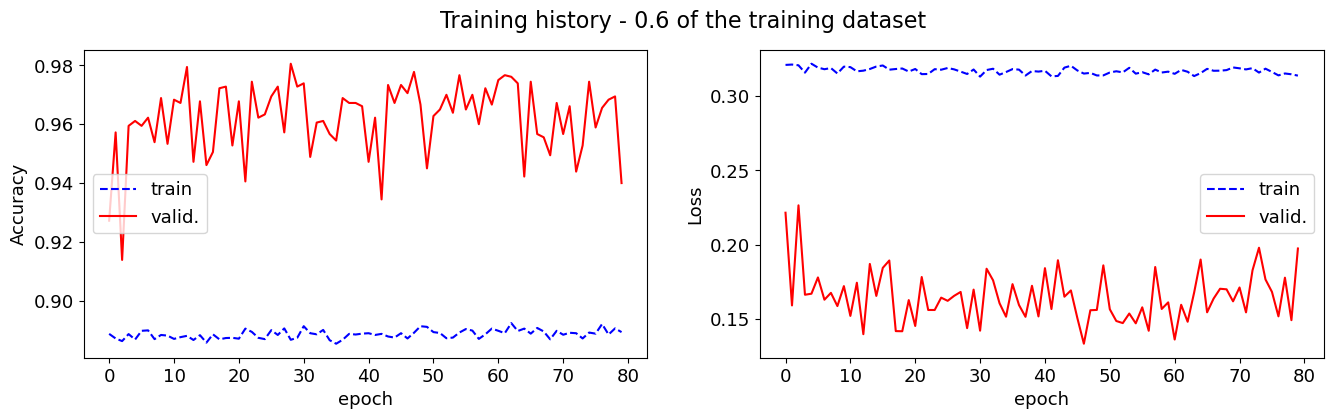

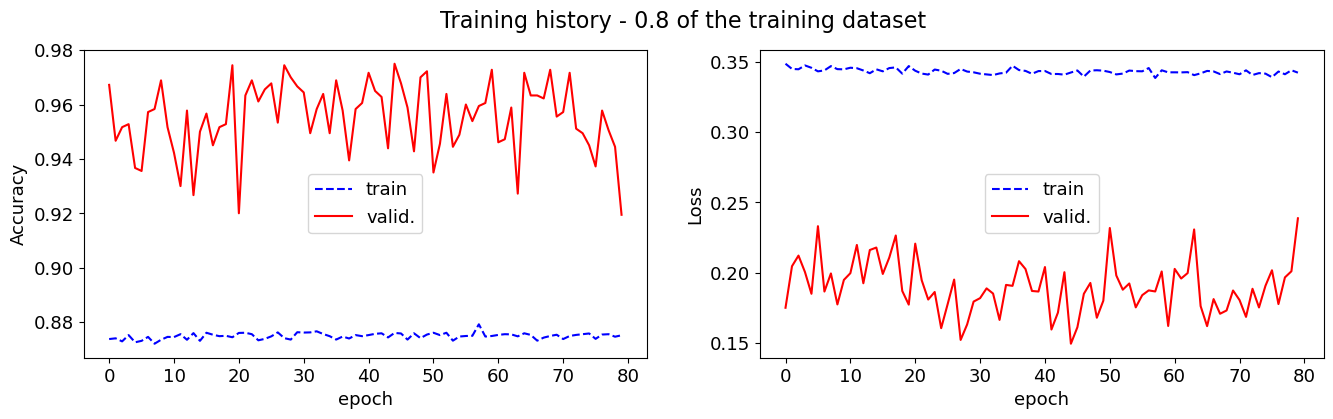

In [134]:
'''
validation for augmented gaussian training sets
'''
best_lag = 1e9
for i,fit in enumerate(Fit_ag):
    fig,AX=plt.subplots(1,2,figsize=(16,4.))
    ax=AX[0]
    fig.suptitle(f'Training history - {perc_aug[i]} of the training dataset', fontsize=16)
    ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_loss'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.legend()
    if fit.history['val_loss'][-1] < best_lag:
        best_l = fit.history['val_loss'][-1]
        best_fit_ag = fit
print(best_lag)
print(best_fit_ag)

In [135]:
'''
training of the model on the augmented non gaussian training sets
'''
Fit_ae = []
for x_train_ae, y_train_ae in zip(aug_xe, aug_ye):
    fit = model.fit(x_train_ae, y_train_ae,
               epochs = nepoch, batch_size = 50,
               validation_data=(x_valid,y_valid),
               verbose=0)
    Fit_ae.append(fit)

1000000000.0


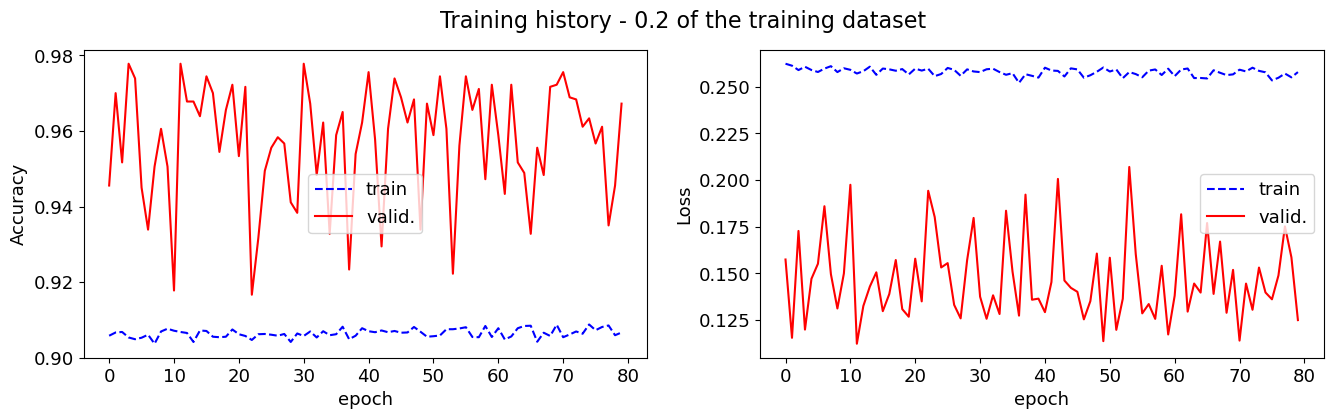

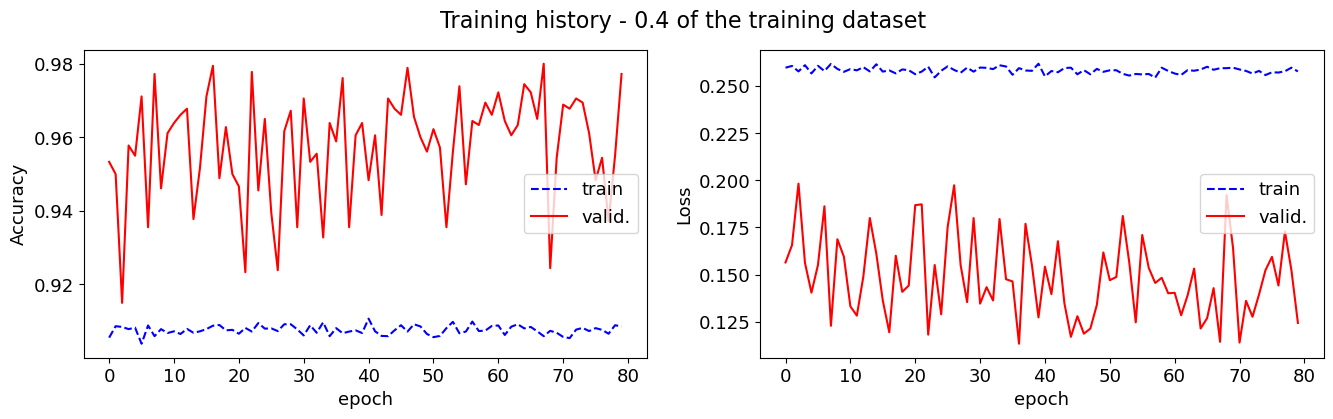

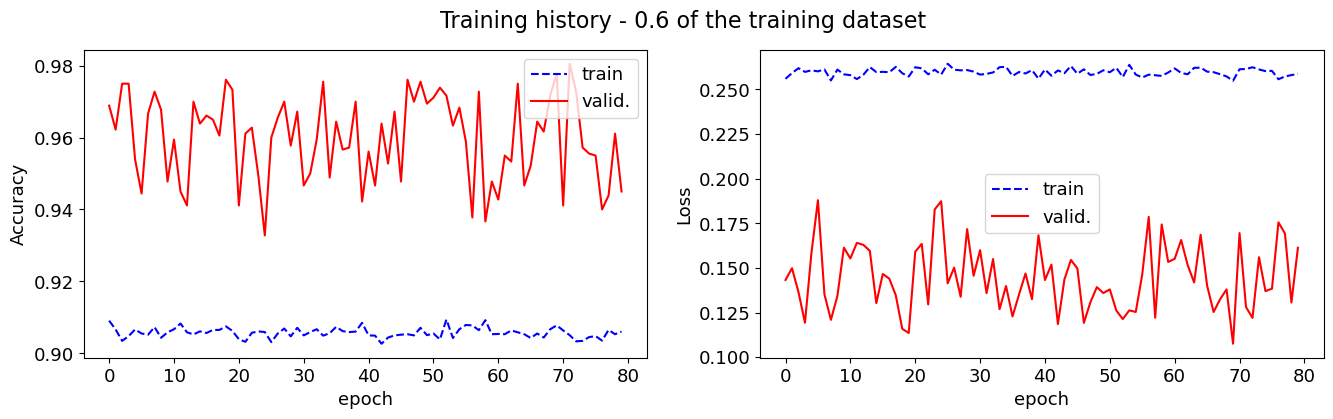

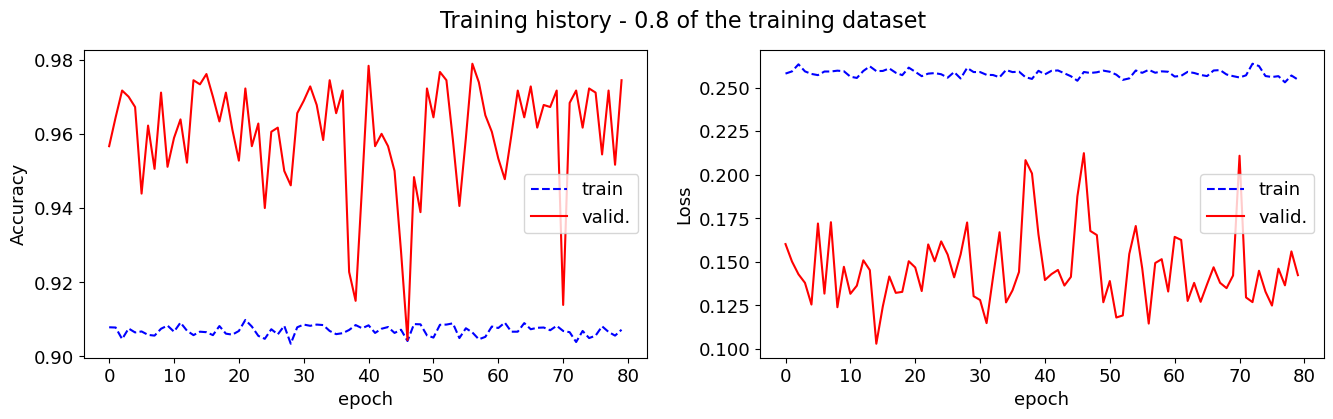

In [136]:
'''
validation for augmented non gaussian training sets
'''
best_lae = 1e9
for i,fit in enumerate(Fit_ae):
    fig,AX=plt.subplots(1,2,figsize=(16,4.))
    ax=AX[0]
    fig.suptitle(f'Training history - {perc_aug[i]} of the training dataset', fontsize=16)
    ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_loss'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.legend()
    if fit.history['val_loss'][-1] < best_lag:
        best_l = fit.history['val_loss'][-1]
        best_fit_ae = fit
print(best_lae)
print(best_fit_ae)

In [115]:
#La validation viene eseguita su ogni dataset modificato, sia reduced che augmented, il confronto tra i modelli avviene tra i risultati della validation
#il test viene eseguito solo sul modello che meglio performa nella validation

In [137]:
min_value = min(best_l, best_lag, best_lae)

if min_value == best_l:
    best_var = "best_l"
elif min_value == best_lag:
    best_var = "best_lag"
else:
    best_var = "best_lae"

print(f"{best_var}")

best_l


In [ ]:
test_loss, test_acc = ******BESTFIT******.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

In [ ]:
#si può aggiungere la grid dal best model sul test